In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk

## Data Cleaning and Preparation

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

categorical_columns = list(
    df.dtypes[df.dtypes == "str"].index
)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(" ", "_")

In [4]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-vhveg,female,0,yes,no,1,no,no_phone_service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic_check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one_year,no,mailed_check,56.95,1889.5,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed_check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no_phone_service,dsl,yes,...,yes,yes,no,no,one_year,no,bank_transfer_(automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber_optic,no,...,no,no,no,no,month-to-month,yes,electronic_check,70.70,151.65,yes


In [5]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors="coerce")

In [6]:
df.totalcharges = df.totalcharges.fillna(0)

In [7]:
df["churn"] = (df.churn == "yes").astype(int)

## Splitting the Dataset into Training and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["churn", "customerid"])
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## EDA

In [9]:
eda_df = X_train.copy()
eda_df["churn"] = y_train

eda_df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
3738,male,0,no,no,35,no,no_phone_service,dsl,no,no,yes,no,yes,yes,month-to-month,no,electronic_check,49.20,1701.65,0
3151,male,0,yes,yes,15,yes,no,fiber_optic,yes,no,no,no,no,no,month-to-month,no,mailed_check,75.10,1151.55,0
4860,male,0,yes,yes,13,no,no_phone_service,dsl,yes,yes,no,yes,no,no,two_year,no,mailed_check,40.55,590.35,0
3867,female,0,yes,no,26,yes,no,dsl,no,yes,yes,no,yes,yes,two_year,yes,credit_card_(automatic),73.50,1905.70,0
3810,male,0,yes,yes,1,yes,no,dsl,no,no,no,no,no,no,month-to-month,no,electronic_check,44.55,44.55,0


### Dataset Overview

In [10]:
eda_df.info()

<class 'pandas.DataFrame'>
Index: 5634 entries, 3738 to 5639
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   str    
 1   seniorcitizen     5634 non-null   int64  
 2   partner           5634 non-null   str    
 3   dependents        5634 non-null   str    
 4   tenure            5634 non-null   int64  
 5   phoneservice      5634 non-null   str    
 6   multiplelines     5634 non-null   str    
 7   internetservice   5634 non-null   str    
 8   onlinesecurity    5634 non-null   str    
 9   onlinebackup      5634 non-null   str    
 10  deviceprotection  5634 non-null   str    
 11  techsupport       5634 non-null   str    
 12  streamingtv       5634 non-null   str    
 13  streamingmovies   5634 non-null   str    
 14  contract          5634 non-null   str    
 15  paperlessbilling  5634 non-null   str    
 16  paymentmethod     5634 non-null   str    
 17  monthlyc

In [11]:
eda_df.describe().T

,count,mean,std,min,25%,50%,75%,max
seniorcitizen,5634.0,0.163294,0.369667,0.0,0.0000,0.000,0.000,1.00
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.000,55.000,72.00
monthlycharges,5634.0,64.929961,30.138105,18.4,35.6625,70.500,90.000,118.75
totalcharges,5634.0,2299.334682,2279.204278,0.0,402.9750,1394.925,3835.825,8684.80
churn,5634.0,0.265353,0.441560,0.0,0.0000,0.000,1.000,1.00


### Data Quality Checks

In [12]:
missing_values = eda_df.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [13]:
eda_df.duplicated().sum()

np.int64(15)

In [14]:
df["customerid"].duplicated().sum()

np.int64(0)

In [15]:
categorical_columns = eda_df.select_dtypes(
    include=["object", "string"]
).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(eda_df[column].value_counts(dropna=False))


gender
gender
male      2833
female    2801
Name: count, dtype: int64

partner
partner
no     2905
yes    2729
Name: count, dtype: int64

dependents
dependents
no     3955
yes    1679
Name: count, dtype: int64

phoneservice
phoneservice
yes    5075
no      559
Name: count, dtype: int64

multiplelines
multiplelines
no                  2685
yes                 2390
no_phone_service     559
Name: count, dtype: int64

internetservice
internetservice
fiber_optic    2483
dsl            1937
no             1214
Name: count, dtype: int64

onlinesecurity
onlinesecurity
no                     2797
yes                    1623
no_internet_service    1214
Name: count, dtype: int64

onlinebackup
onlinebackup
no                     2442
yes                    1978
no_internet_service    1214
Name: count, dtype: int64

deviceprotection
deviceprotection
no                     2472
yes                    1948
no_internet_service    1214
Name: count, dtype: int64

techsupport
techsupport
no             

### Churn Distribution

In [16]:
eda_df["churn"].value_counts()

churn
0    4139
1    1495
Name: count, dtype: int64

In [17]:
eda_df["churn"].value_counts(normalize=True)

churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

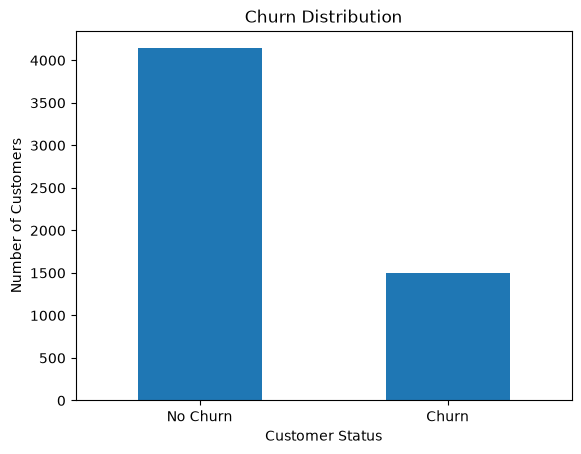

In [18]:
import matplotlib.pyplot as plt

churn_counts = eda_df["churn"].value_counts().sort_index()

churn_counts.index = ["No Churn", "Churn"]

churn_counts.plot(kind="bar")

plt.title("Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Numerical Feature Distributions

In [20]:
numerical_columns = [
    "tenure",
    "monthlycharges",
    "totalcharges"
]

eda_df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.000,55.000,72.00
monthlycharges,5634.0,64.929961,30.138105,18.4,35.6625,70.500,90.000,118.75
totalcharges,5634.0,2299.334682,2279.204278,0.0,402.9750,1394.925,3835.825,8684.80


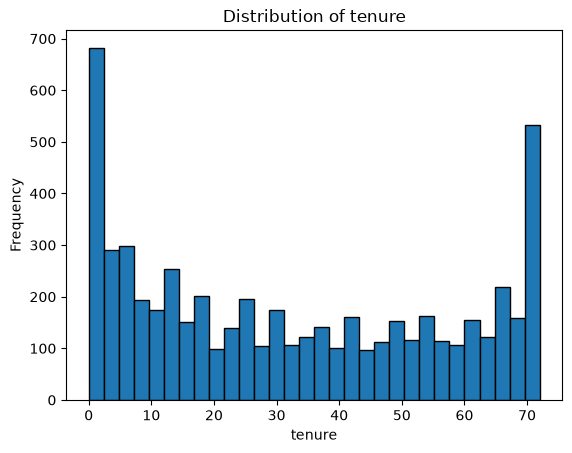

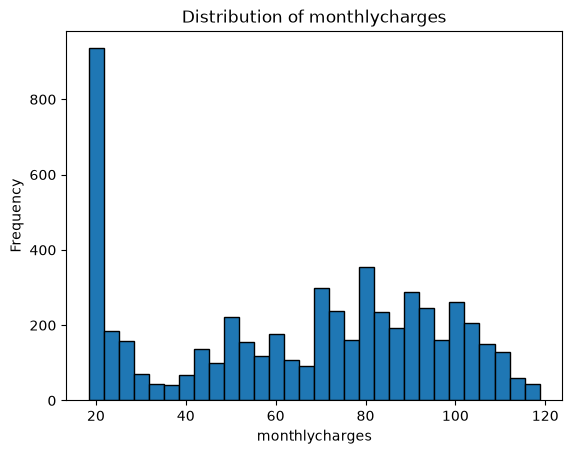

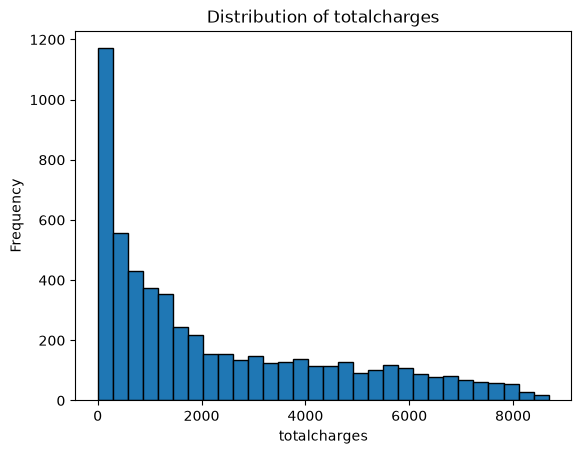

In [21]:
for column in numerical_columns:
    eda_df[column].plot(
        kind="hist",
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Numerical Features by Churn Status

In [23]:
eda_df.groupby("churn")[numerical_columns].mean()

,tenure,monthlycharges,totalcharges
churn,,,
0,37.587582,61.343187,2564.724015
1,18.358528,74.860167,1564.587893


In [24]:
eda_df.groupby("churn")[numerical_columns].median()

,tenure,monthlycharges,totalcharges
churn,,,
0,38.0,64.40,1686.15
1,10.0,79.95,740.30


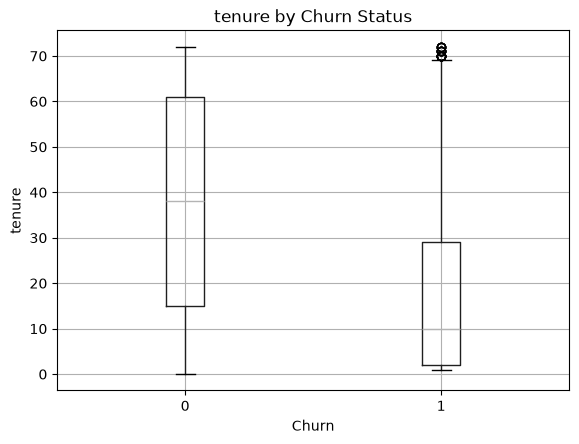

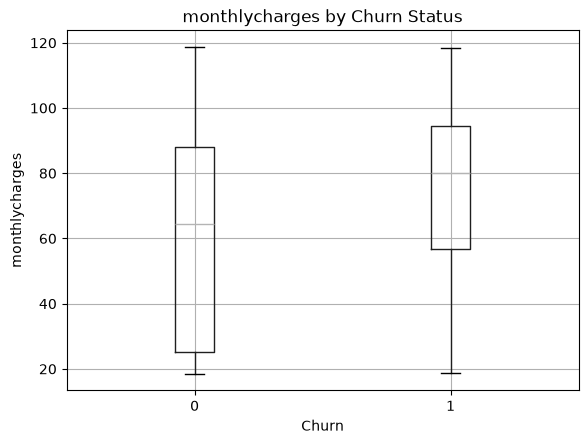

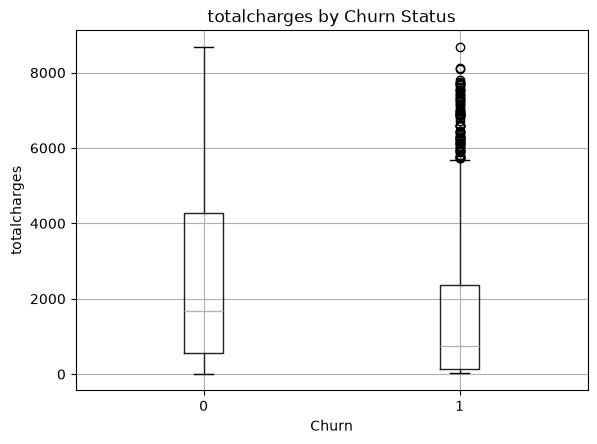

In [25]:
for column in numerical_columns:
    eda_df.boxplot(
        column=column,
        by="churn"
    )

    plt.title(f"{column} by Churn Status")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(column)
    plt.show()

### Churn Rate by Categorical Features

In [26]:
important_categorical_columns = [
    "contract",
    "internetservice",
    "paymentmethod",
    "techsupport",
    "onlinesecurity",
    "onlinebackup",
    "deviceprotection",
    "paperlessbilling",
    "partner",
    "dependents"
]

In [27]:
def plot_churn_rate(column):
    churn_rate = (
        eda_df
        .groupby(column)["churn"]
        .mean()
        .sort_values()
    )

    churn_rate.plot(kind="barh")

    plt.title(f"Churn Rate by {column}")
    plt.xlabel("Churn Rate")
    plt.ylabel(column)
    plt.xlim(0, 1)
    plt.show()

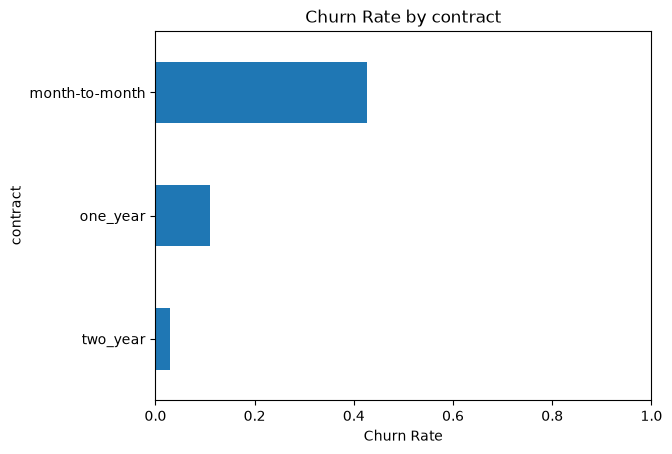

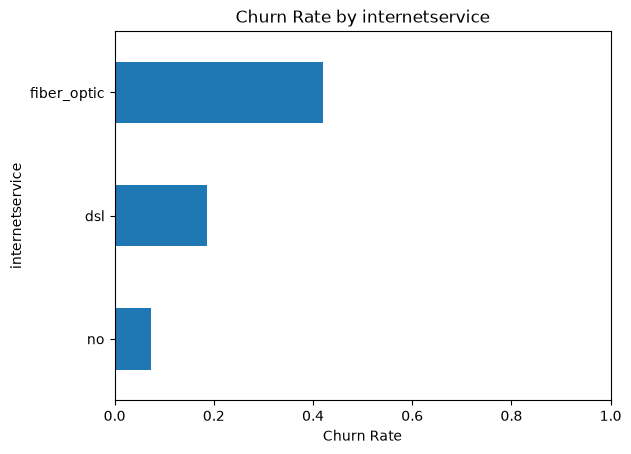

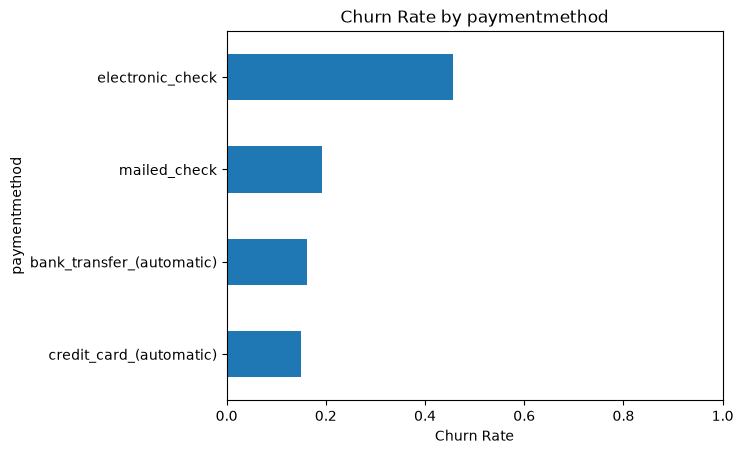

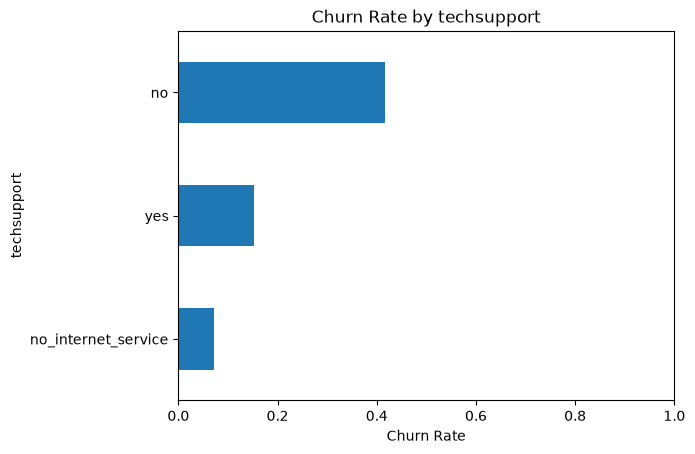

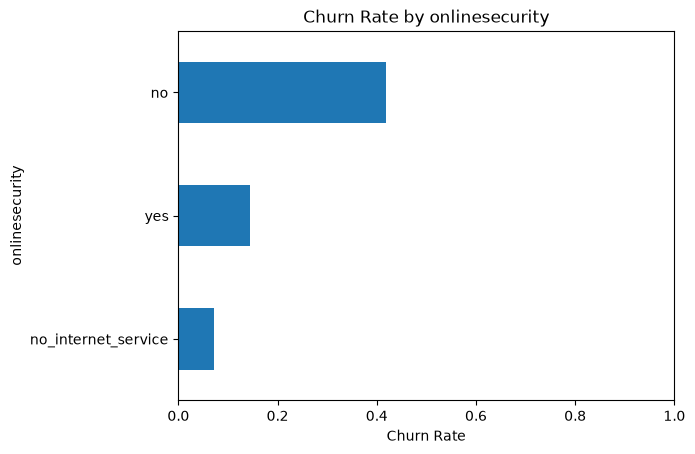

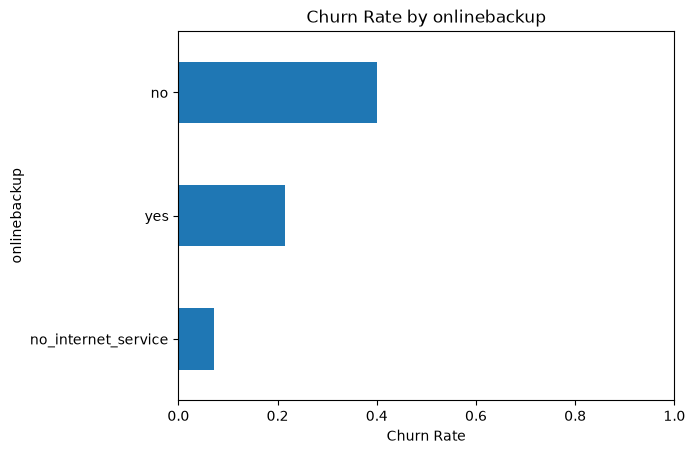

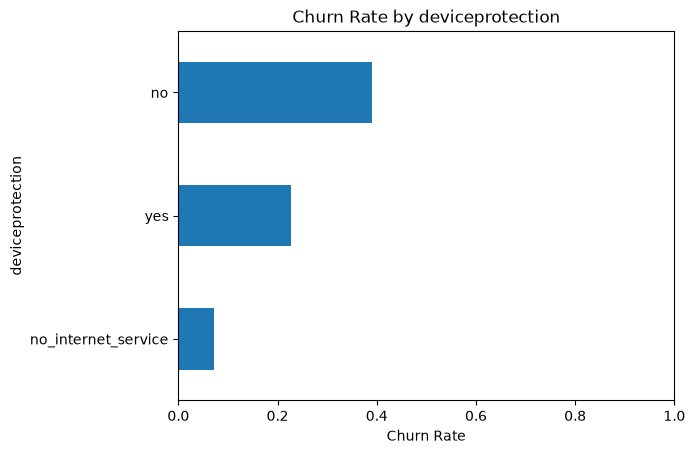

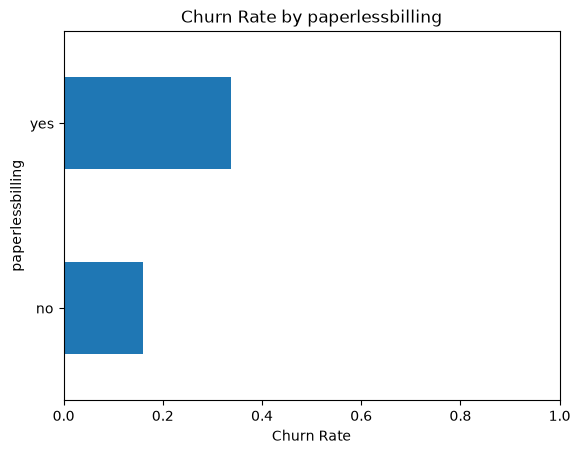

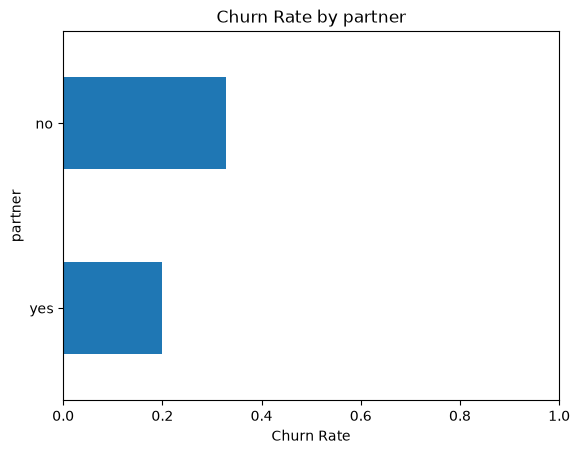

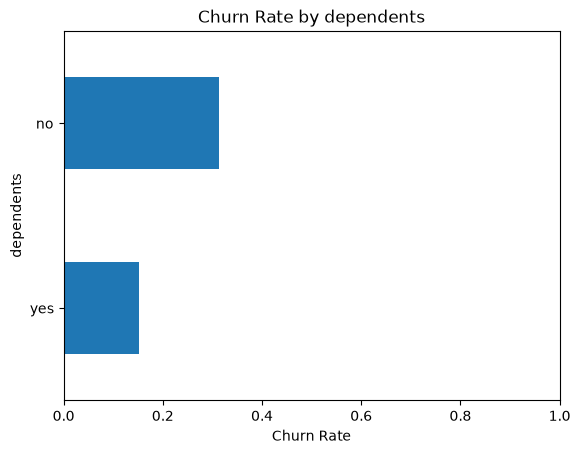

In [30]:
for column in important_categorical_columns:
    plot_churn_rate(column)

### Churn Rate by Senior Citizen Status

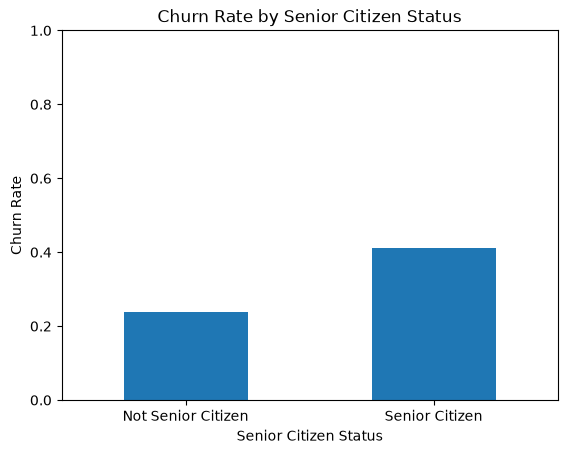

In [31]:
senior_churn = (
    eda_df
    .groupby("seniorcitizen")["churn"]
    .mean()
)

senior_churn.index = [
    "Not Senior Citizen",
    "Senior Citizen"
]

senior_churn.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

In [32]:
eda_df["tenure_group"] = pd.cut(
    eda_df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=[
        "0–12 months",
        "13–24 months",
        "25–48 months",
        "49–60 months",
        "61–72 months"
    ]
)

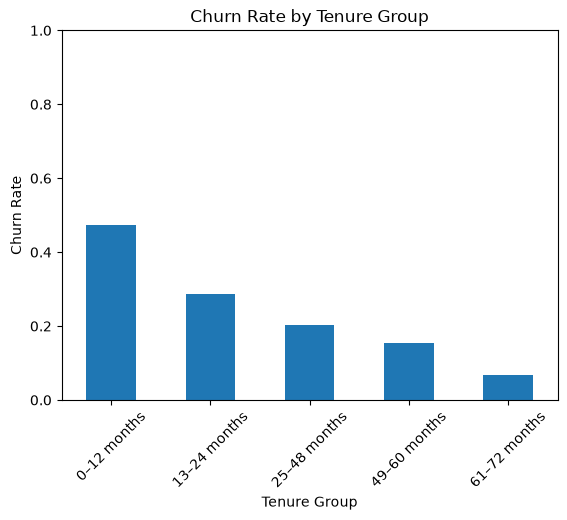

In [33]:
tenure_churn_rate = (
    eda_df
    .groupby("tenure_group", observed=False)["churn"]
    .mean()
)

tenure_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

### Correlation Analysis

In [34]:
correlation_columns = [
    "seniorcitizen",
    "tenure",
    "monthlycharges",
    "totalcharges",
    "churn"
]

correlation_matrix = eda_df[correlation_columns].corr()

correlation_matrix

,seniorcitizen,tenure,monthlycharges,totalcharges,churn
seniorcitizen,1.000000,0.016980,0.220376,0.102318,0.145599
tenure,0.016980,1.000000,0.256700,0.829698,-0.345593
monthlycharges,0.220376,0.256700,1.000000,0.654117,0.198040
totalcharges,0.102318,0.829698,0.654117,1.000000,-0.193761
churn,0.145599,-0.345593,0.198040,-0.193761,1.000000
